# Notebook 2 — Feature Engineering & Social Prescription Recommendation (Age ≥ 65)

This notebook loads the baseline analytic dataset produced by Notebook 1 and builds:
1) an interpretable risk score,
2) a transparent rule-based recommendation engine (social prescription),
3) coverage checks (overall + subgroups).

**Input from Notebook 1**
- `../data_processed/hrs_baseline_analytic.csv`

**Outputs from this notebook**
- `../data_processed/notebook2_recommendations.csv`
- `../data_processed/notebook2_coverage_report.csv`
- plots for risk score distribution and recommendation coverage

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

DATA_DIR = "../data_processed"
INFILE = os.path.join(DATA_DIR, "hrs_baseline_analytic.csv")

OUT_RECO = os.path.join(DATA_DIR, "notebook2_recommendations.csv")
OUT_COVERAGE = os.path.join(DATA_DIR, "notebook2_coverage_report.csv")

print("CWD:", os.getcwd())
print("INFILE:", INFILE)
print("Exists:", os.path.exists(INFILE))

CWD: c:\Users\Yu\Desktop\BMI5111_Capstone_YuJun\notebooks
INFILE: ../data_processed\hrs_baseline_analytic.csv
Exists: True


In [2]:
df = pd.read_csv(INFILE)
print("Loaded:", df.shape)
df.head()

Loaded: (11412, 10)


,hhidpn,wave,age,gender,diabetes,adl_any,cesd,hosp,high_risk,next_hosp
0,3010,1,77.0,2.female,0.0,0.0,0.0,0.0,0,0.0
1,3020,1,77.0,1.male,0.0,0.0,0.0,0.0,0,1.0
2,10003030,1,65.0,1.male,0.0,1.0,0.0,0.0,1,0.0
3,10004040,1,71.0,1.male,0.0,0.0,0.0,0.0,0,0.0
4,10013040,1,78.0,1.male,0.0,0.0,0.0,0.0,0,0.0


In [3]:
print(df.columns.tolist())
df.describe(include="all").T.head(20)

['hhidpn', 'wave', 'age', 'gender', 'diabetes', 'adl_any', 'cesd', 'hosp', 'high_risk', 'next_hosp']


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hhidpn,11412.0,NaN,NaN,NaN,147990051.575272,121929026.932459,3010.0,50758767.5,200531015.0,206116012.5,920557010.0
wave,11412.0,NaN,NaN,NaN,2.427094,2.063074,1.0,1.0,2.0,2.0,15.0
age,11412.0,NaN,NaN,NaN,80.984753,8.315957,65.0,75.0,81.0,87.0,110.0
gender,4554,2,1.male,2786,NaN,NaN,NaN,NaN,NaN,NaN,NaN
diabetes,11412.0,NaN,NaN,NaN,0.129776,0.336071,0.0,0.0,0.0,0.0,1.0
adl_any,11243.0,NaN,NaN,NaN,0.097216,0.296265,0.0,0.0,0.0,0.0,1.0
cesd,10703.0,NaN,NaN,NaN,0.811828,1.574685,0.0,0.0,0.0,1.0,8.0
hosp,11395.0,NaN,NaN,NaN,0.183853,0.387381,0.0,0.0,0.0,0.0,1.0
high_risk,11412.0,NaN,NaN,NaN,0.297757,0.457292,0.0,0.0,0.0,1.0,1.0
next_hosp,10383.0,NaN,NaN,NaN,0.236637,0.425038,0.0,0.0,0.0,0.0,1.0


## 1) Basic cleaning / type fixes

We keep the dataset as-is (already baseline analytic from Notebook 1), and only do minimal safety conversions.

In [5]:
data = df.copy()

# Strip column names
data.columns = [c.strip() for c in data.columns]

# Convert obvious numeric columns to numeric when possible
for c in data.columns:
    if data[c].dtype == "object":
        # try numeric conversion; if too many become NaN, keep as object
        tmp = pd.to_numeric(data[c], errors="coerce")
        # if at least 70% convertible, replace
        if tmp.notna().mean() >= 0.7:
            data[c] = tmp

print(data.dtypes)
data.head()

hhidpn         int64
wave           int64
age          float64
gender           str
diabetes     float64
adl_any      float64
cesd         float64
hosp         float64
high_risk      int64
next_hosp    float64
dtype: object


,hhidpn,wave,age,gender,diabetes,adl_any,cesd,hosp,high_risk,next_hosp
0,3010,1,77.0,2.female,0.0,0.0,0.0,0.0,0,0.0
1,3020,1,77.0,1.male,0.0,0.0,0.0,0.0,0,1.0
2,10003030,1,65.0,1.male,0.0,1.0,0.0,0.0,1,0.0
3,10004040,1,71.0,1.male,0.0,0.0,0.0,0.0,0,0.0
4,10013040,1,78.0,1.male,0.0,0.0,0.0,0.0,0,0.0


## 2) Identify key columns

Notebook 1 output seems to contain variables like:
- hosp, next_hosp, high_risk

We will:
- infer ID column (if exists)
- infer age column (if exists) and apply Age ≥ 65 filter if age is present
- build risk_score from available predictors (fallback strategy if some columns are missing)

In [7]:
def pick_first_existing_col(df, candidates, required=False):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"None of the candidate columns exist: {candidates}")
    return None

id_col = pick_first_existing_col(data, ["hhidpn", "HHIDPN", "id", "ID", "person_id"], required=False)
age_col = pick_first_existing_col(data, ["age", "AGE", "r_age", "baseline_age"], required=False)
sex_col = pick_first_existing_col(data, ["female", "sex", "SEX", "gender"], required=False)

print("id_col:", id_col)
print("age_col:", age_col)
print("sex_col:", sex_col)

# If age exists, enforce Age ≥ 65 (instructor requirement)
if age_col is not None:
    data[age_col] = pd.to_numeric(data[age_col], errors="coerce")
    before = data.shape[0]
    data = data[data[age_col] >= 65].copy()
    after = data.shape[0]
    print(f"Applied age>=65 filter: {before} -> {after}")
else:
    print("No age column found; skip age>=65 filter (dataset may already be restricted).")

data.head()

id_col: hhidpn
age_col: age
sex_col: gender
Applied age>=65 filter: 11412 -> 11412


,hhidpn,wave,age,gender,diabetes,adl_any,cesd,hosp,high_risk,next_hosp
0,3010,1,77.0,2.female,0.0,0.0,0.0,0.0,0,0.0
1,3020,1,77.0,1.male,0.0,0.0,0.0,0.0,0,1.0
2,10003030,1,65.0,1.male,0.0,1.0,0.0,0.0,1,0.0
3,10004040,1,71.0,1.male,0.0,0.0,0.0,0.0,0,0.0
4,10013040,1,78.0,1.male,0.0,0.0,0.0,0.0,0,0.0


## 3) Coverage report

We quantify missingness of each column (basic transparency).

In [8]:
coverage_df = pd.DataFrame({
    "column": data.columns,
    "missing_rate": [float(data[c].isna().mean()) for c in data.columns],
    "dtype": [str(data[c].dtype) for c in data.columns]
}).sort_values("missing_rate", ascending=False)

coverage_df.to_csv(OUT_COVERAGE, index=False)
coverage_df.head(30)

,column,missing_rate,dtype
3,gender,0.600946,str
9,next_hosp,0.090168,float64
6,cesd,0.062128,float64
5,adl_any,0.014809,float64
7,hosp,0.001490,float64
0,hhidpn,0.000000,int64
1,wave,0.000000,int64
2,age,0.000000,float64
4,diabetes,0.000000,float64
8,high_risk,0.000000,int64


## 4) Risk score (interpretable, robust to missing columns)

We build a simple risk score from available columns.
Priority components:
- baseline hosp utilization (if exists): hosp
- baseline chronic burden / functional limits (if exists)
- prior 'high_risk' (if exists) can be used as a component or benchmark

If only hosp/high_risk exist, we still produce a numeric risk_score.

In [9]:
# Candidate predictors — these are guesses; the code will only use those that exist.
candidate_features = [
    "hosp", "ed", "gp", "outpatient", "inpatient",
    "n_chronic", "adl_score", "iadl_score", "cesd", "lonely",
    "income", "wealth", "edu"
]

available = [c for c in candidate_features if c in data.columns]
print("Available features for risk_score:", available)

X = pd.DataFrame(index=data.index)

for c in available:
    X[c] = pd.to_numeric(data[c], errors="coerce")

# Standardize (z-score) for stable weighting
Z = pd.DataFrame(index=X.index)
for c in X.columns:
    mu = X[c].mean(skipna=True)
    sd = X[c].std(skipna=True)
    if pd.isna(sd) or sd == 0:
        Z[c] = 0.0
    else:
        Z[c] = (X[c] - mu) / sd

# Simple weights: utilization gets higher weight
weights = {}
for c in Z.columns:
    if c in ["hosp", "ed", "inpatient"]:
        weights[c] = 0.35
    elif c in ["gp", "outpatient"]:
        weights[c] = 0.20
    else:
        weights[c] = 0.15

# Normalize weights to sum to 1 over available columns
if len(weights) == 0:
    data["risk_score"] = 0.0
else:
    wsum = sum(weights.values())
    for k in weights:
        weights[k] /= wsum

    data["risk_score"] = 0.0
    for c, w in weights.items():
        data["risk_score"] = data["risk_score"] + w * Z[c].fillna(0)

# Define high risk by top 20% of risk_score if not already present
if "high_risk" not in data.columns:
    thr = data["risk_score"].quantile(0.80)
    data["high_risk"] = (data["risk_score"] >= thr).astype(int)
else:
    # try ensure numeric
    data["high_risk"] = pd.to_numeric(data["high_risk"], errors="coerce")

data[["risk_score", "high_risk"]].describe(include="all")

Available features for risk_score: ['hosp', 'cesd']


,risk_score,high_risk
count,1.141200e+04,11412.000000
mean,1.992409e-17,0.297757
std,7.930559e-01,0.457292
min,-4.868878e-01,0.000000
25%,-4.868878e-01,0.000000
50%,-4.868878e-01,0.000000
75%,8.465515e-02,1.000000
max,2.844234e+00,1.000000


## 5) Recommendation engine (rule-based + reason codes)

We generate top-3 social prescription recommendations.
Rules adapt to available columns; if a signal is missing, that rule is skipped.

Output fields:
- top1, top2, top3
- reasons (joined)
- n_recs
- has_reco

In [10]:
def recommend_row(row):
    recs = []
    reasons = []

    # Rule A: high utilization / hosp -> care coordination / telehealth follow-up
    if "hosp" in row and pd.notna(row["hosp"]) and row["hosp"] >= 1:
        recs.append("Care coordination / follow-up")
        reasons.append("Baseline hospitalization (hosp>=1)")

    # Rule B: high_risk -> proactive outreach
    if "high_risk" in row and pd.notna(row["high_risk"]) and row["high_risk"] == 1:
        recs.append("Proactive outreach / case management")
        reasons.append("High risk flag (high_risk==1)")

    # Rule C: chronic/functional/mental health/social needs (only if columns exist)
    if "n_chronic" in row and pd.notna(row["n_chronic"]) and row["n_chronic"] >= 2:
        recs.append("Lifestyle & chronic disease coaching")
        reasons.append("Multiple chronic conditions (n_chronic>=2)")

    if "adl_score" in row and pd.notna(row["adl_score"]) and row["adl_score"] >= 2:
        recs.append("Community care / home support")
        reasons.append("Functional limitation (adl_score>=2)")

    if "cesd" in row and pd.notna(row["cesd"]) and row["cesd"] >= 8:
        recs.append("Mental health support")
        reasons.append("Elevated depressive symptoms (cesd>=8)")

    if "lonely" in row and pd.notna(row["lonely"]) and row["lonely"] >= 2:
        recs.append("Social connection programme")
        reasons.append("Loneliness proxy (lonely>=2)")

    # If still empty, provide a low-intensity generic recommendation
    if len(recs) == 0:
        recs.append("General community resource information")
        reasons.append("No specific trigger; provide low-intensity support")

    # De-duplicate while preserving order; take top-3
    seen = set()
    recs2, reasons2 = [], []
    for r, rsn in zip(recs, reasons):
        if r not in seen:
            recs2.append(r)
            reasons2.append(rsn)
            seen.add(r)

    recs2 = recs2[:3]
    reasons2 = reasons2[:3]

    return pd.Series({
        "top1": recs2[0] if len(recs2) > 0 else None,
        "top2": recs2[1] if len(recs2) > 1 else None,
        "top3": recs2[2] if len(recs2) > 2 else None,
        "reasons": " | ".join(reasons2),
        "n_recs": len(recs2)
    })

In [11]:
reco = data.apply(recommend_row, axis=1)
result = pd.concat([data, reco], axis=1)
result["has_reco"] = (result["n_recs"] > 0).astype(int)

print("Result shape:", result.shape)
result[[c for c in ["risk_score","high_risk","top1","top2","top3","reasons","n_recs","has_reco"] if c in result.columns]].head(10)

Result shape: (11412, 17)


,risk_score,high_risk,top1,top2,top3,reasons,n_recs,has_reco
0,-0.486888,0,General community resource information,NaN,NaN,No specific trigger; provide low-intensity sup...,1,1
1,-0.486888,0,General community resource information,NaN,NaN,No specific trigger; provide low-intensity sup...,1,1
2,-0.486888,1,Proactive outreach / case management,NaN,NaN,High risk flag (high_risk==1),1,1
3,-0.486888,0,General community resource information,NaN,NaN,No specific trigger; provide low-intensity sup...,1,1
4,-0.486888,0,General community resource information,NaN,NaN,No specific trigger; provide low-intensity sup...,1,1
5,-0.486888,0,General community resource information,NaN,NaN,No specific trigger; provide low-intensity sup...,1,1
6,-0.105859,1,Proactive outreach / case management,NaN,NaN,High risk flag (high_risk==1),1,1
7,1.320119,1,Care coordination / follow-up,Proactive outreach / case management,NaN,Baseline hospitalization (hosp>=1) | High risk...,2,1
8,1.320119,0,Care coordination / follow-up,NaN,NaN,Baseline hospitalization (hosp>=1),1,1
9,-0.486888,0,General community resource information,NaN,NaN,No specific trigger; provide low-intensity sup...,1,1


## 6) Coverage checks (overall + subgroup)

We report:
- overall % with at least 1 recommendation
- by sex (if available)
- by age bands (if age exists)

Overall recommendation coverage: 1.0

Coverage by sex:
gender
1.male      1.0
2.female    1.0
Name: has_reco, dtype: float64

Coverage by age group:
_age_group
65-69    1.0
70-74    1.0
75-79    1.0
80-84    1.0
85+      1.0
Name: has_reco, dtype: float64


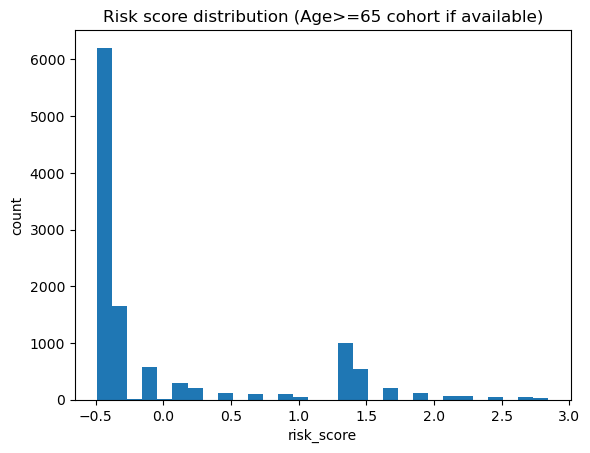

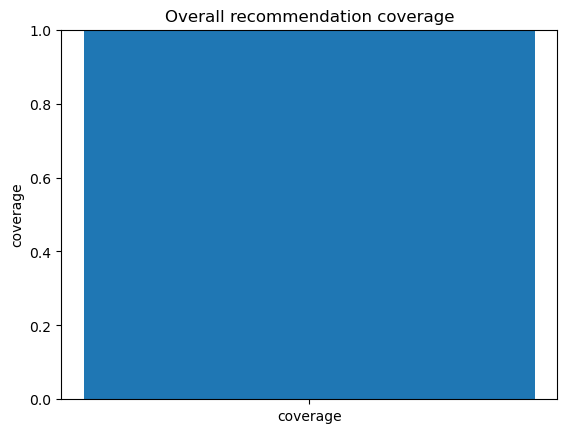

In [12]:
overall_cov = float(result["has_reco"].mean())
print("Overall recommendation coverage:", overall_cov)

# by sex
if sex_col is not None and sex_col in result.columns and result[sex_col].notna().any():
    print("\nCoverage by sex:")
    print(result.groupby(sex_col)["has_reco"].mean())
else:
    print("\nNo usable sex column; skip sex subgroup check.")

# by age groups
if age_col is not None and age_col in result.columns and result[age_col].notna().any():
    age = pd.to_numeric(result[age_col], errors="coerce")
    age_group = pd.cut(age, bins=[0, 69, 74, 79, 84, 200], labels=["65-69","70-74","75-79","80-84","85+"])
    result["_age_group"] = age_group
    print("\nCoverage by age group:")
    print(result.groupby("_age_group")["has_reco"].mean())
else:
    print("\nNo usable age column; skip age subgroup check.")

# plots
plt.figure()
plt.hist(result["risk_score"].dropna(), bins=30)
plt.title("Risk score distribution (Age>=65 cohort if available)")
plt.xlabel("risk_score")
plt.ylabel("count")
plt.show()

plt.figure()
plt.bar(["coverage"], [overall_cov])
plt.ylim(0, 1)
plt.title("Overall recommendation coverage")
plt.ylabel("coverage")
plt.show()

## 7) Save outputs

In [13]:
result.to_csv(OUT_RECO, index=False)
print("Saved recommendations to:", OUT_RECO)
print("Saved coverage report to:", OUT_COVERAGE)

Saved recommendations to: ../data_processed\notebook2_recommendations.csv
Saved coverage report to: ../data_processed\notebook2_coverage_report.csv
